In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open(f'./results/raw_times.pkl', 'rb') as f:
            raw_times = pickle.load(f)
with open(f'./results/norm_times.pkl', 'rb') as f:
            norm_times = pickle.load(f)

## Summary

In [3]:
raw_df = pd.DataFrame.from_dict(raw_times)
raw_df.describe()

,shortest_paths_obj,shortest_distances_obj,motifs_obj,Average Degree for Nearest Neighbors (Undirected),Clustering Coefficient,Rich Club Coefficient,Average Local Efficiency,Average Shortest Path Length,Betweenness Centrality,Center,...,Max Out-Degree,Number of Arcs,Out-Degree,Regulators,Self Regulations,Gene % in the Giant Component,Undirected Density,get_props,edges,nodes
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.0,25.0,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,0.000520,0.001440,0.002721,0.002360,0.006720,0.004176,0.002560,0.0,0.0,0.003640,...,0.000280,0.000400,0.000140,0.000160,0.000920,0.000180,0.000080,0.223342,442.360000,462.360000
std,0.000587,0.000651,0.000844,0.001111,0.001975,0.001147,0.000822,0.0,0.0,0.000810,...,0.000542,0.000500,0.000339,0.000373,0.000641,0.000431,0.000277,0.093501,71.268202,71.268202
min,0.000000,0.000000,0.000999,0.000999,0.003998,0.002510,0.000999,0.0,0.0,0.001995,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.128520,342.000000,362.000000
25%,0.000000,0.001000,0.002000,0.002000,0.005002,0.003005,0.001999,0.0,0.0,0.002999,...,0.000000,0.000000,0.000000,0.000000,0.000999,0.000000,0.000000,0.145976,381.000000,401.000000
50%,0.000000,0.001003,0.002999,0.002002,0.006508,0.004001,0.002007,0.0,0.0,0.003996,...,0.000000,0.000000,0.000000,0.000000,0.001000,0.000000,0.000000,0.196068,427.000000,447.000000
75%,0.001000,0.002000,0.003004,0.002996,0.007001,0.005001,0.003000,0.0,0.0,0.004002,...,0.000000,0.000999,0.000000,0.000000,0.001001,0.000000,0.000000,0.290560,517.000000,537.000000
max,0.002011,0.002999,0.004007,0.006989,0.012999,0.007003,0.005016,0.0,0.0,0.005002,...,0.002003,0.001010,0.001000,0.001000,0.003006,0.001506,0.001003,0.411075,550.000000,570.000000


## Overall times

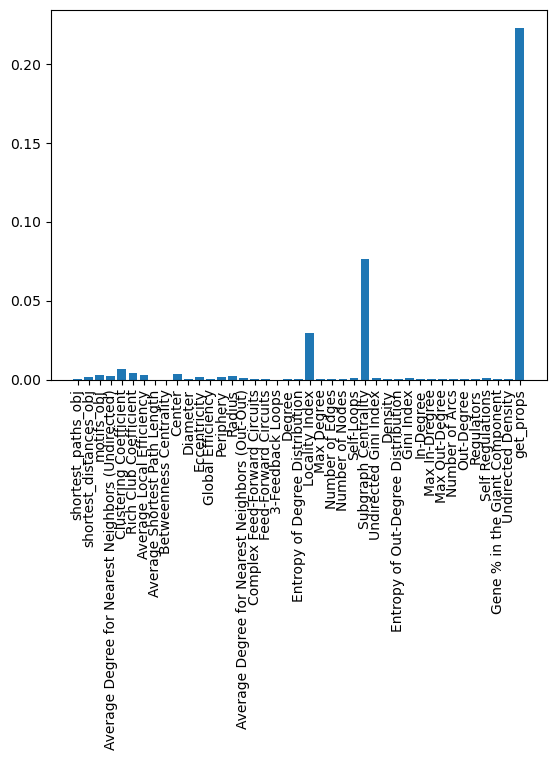

In [4]:
raw_means = {}

for prop, times in raw_times.items():
    if prop != 'edges' and prop != 'nodes':
        raw_means[prop] = np.asarray(times).mean()

names = list(raw_means.keys())
values = list(raw_means.values())

plt.bar(range(len(raw_means)), values, tick_label=names, align='center')
plt.xticks(rotation = 90)
plt.show()

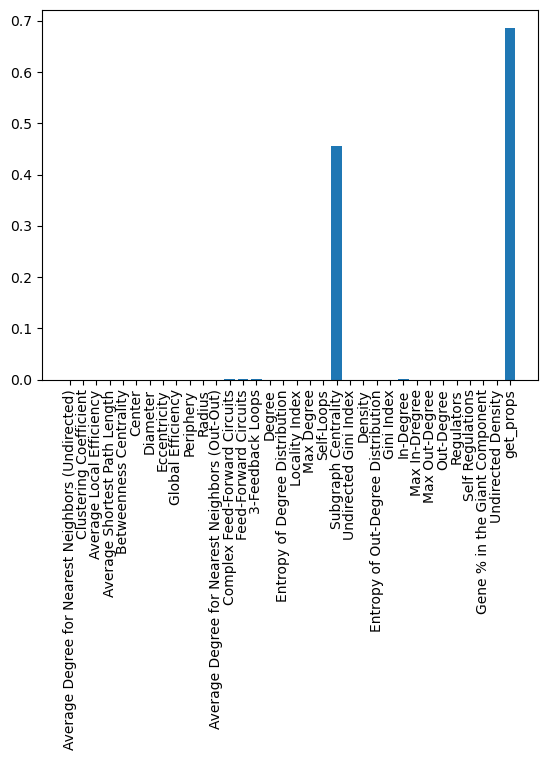

In [5]:
norm_means = {}
for prop, times in norm_times.items():
    if prop != 'edges' and prop != 'nodes':
        norm_means[prop] = np.asarray(times).mean()

names = list(norm_means.keys())
values = list(norm_means.values())

plt.bar(range(len(norm_means)), values, tick_label=names, align='center')
plt.xticks(rotation = 90)
plt.show()

## Relationship between number of edges and computing times

In [6]:
final_df = pd.DataFrame()
for i,(prop, times) in enumerate(raw_times.items()):
    if prop != 'edges' and prop != 'nodes':
        df = pd.DataFrame({'Process': prop, 'Edges': raw_df['edges'], 'Time (s)': times})
        final_df = pd.concat([final_df, df])

final_df

,Process,Edges,Time (s)
0,shortest_paths_obj,366,0.000999
1,shortest_paths_obj,342,0.000000
2,shortest_paths_obj,363,0.000000
3,shortest_paths_obj,408,0.001000
4,shortest_paths_obj,427,0.000000
...,...,...,...
20,get_props,409,0.306484
21,get_props,405,0.202478
22,get_props,543,0.303543
23,get_props,541,0.153038


c:\Users\PepeS\miniconda3\envs\netective\lib\site-packages\seaborn\regression.py:582: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


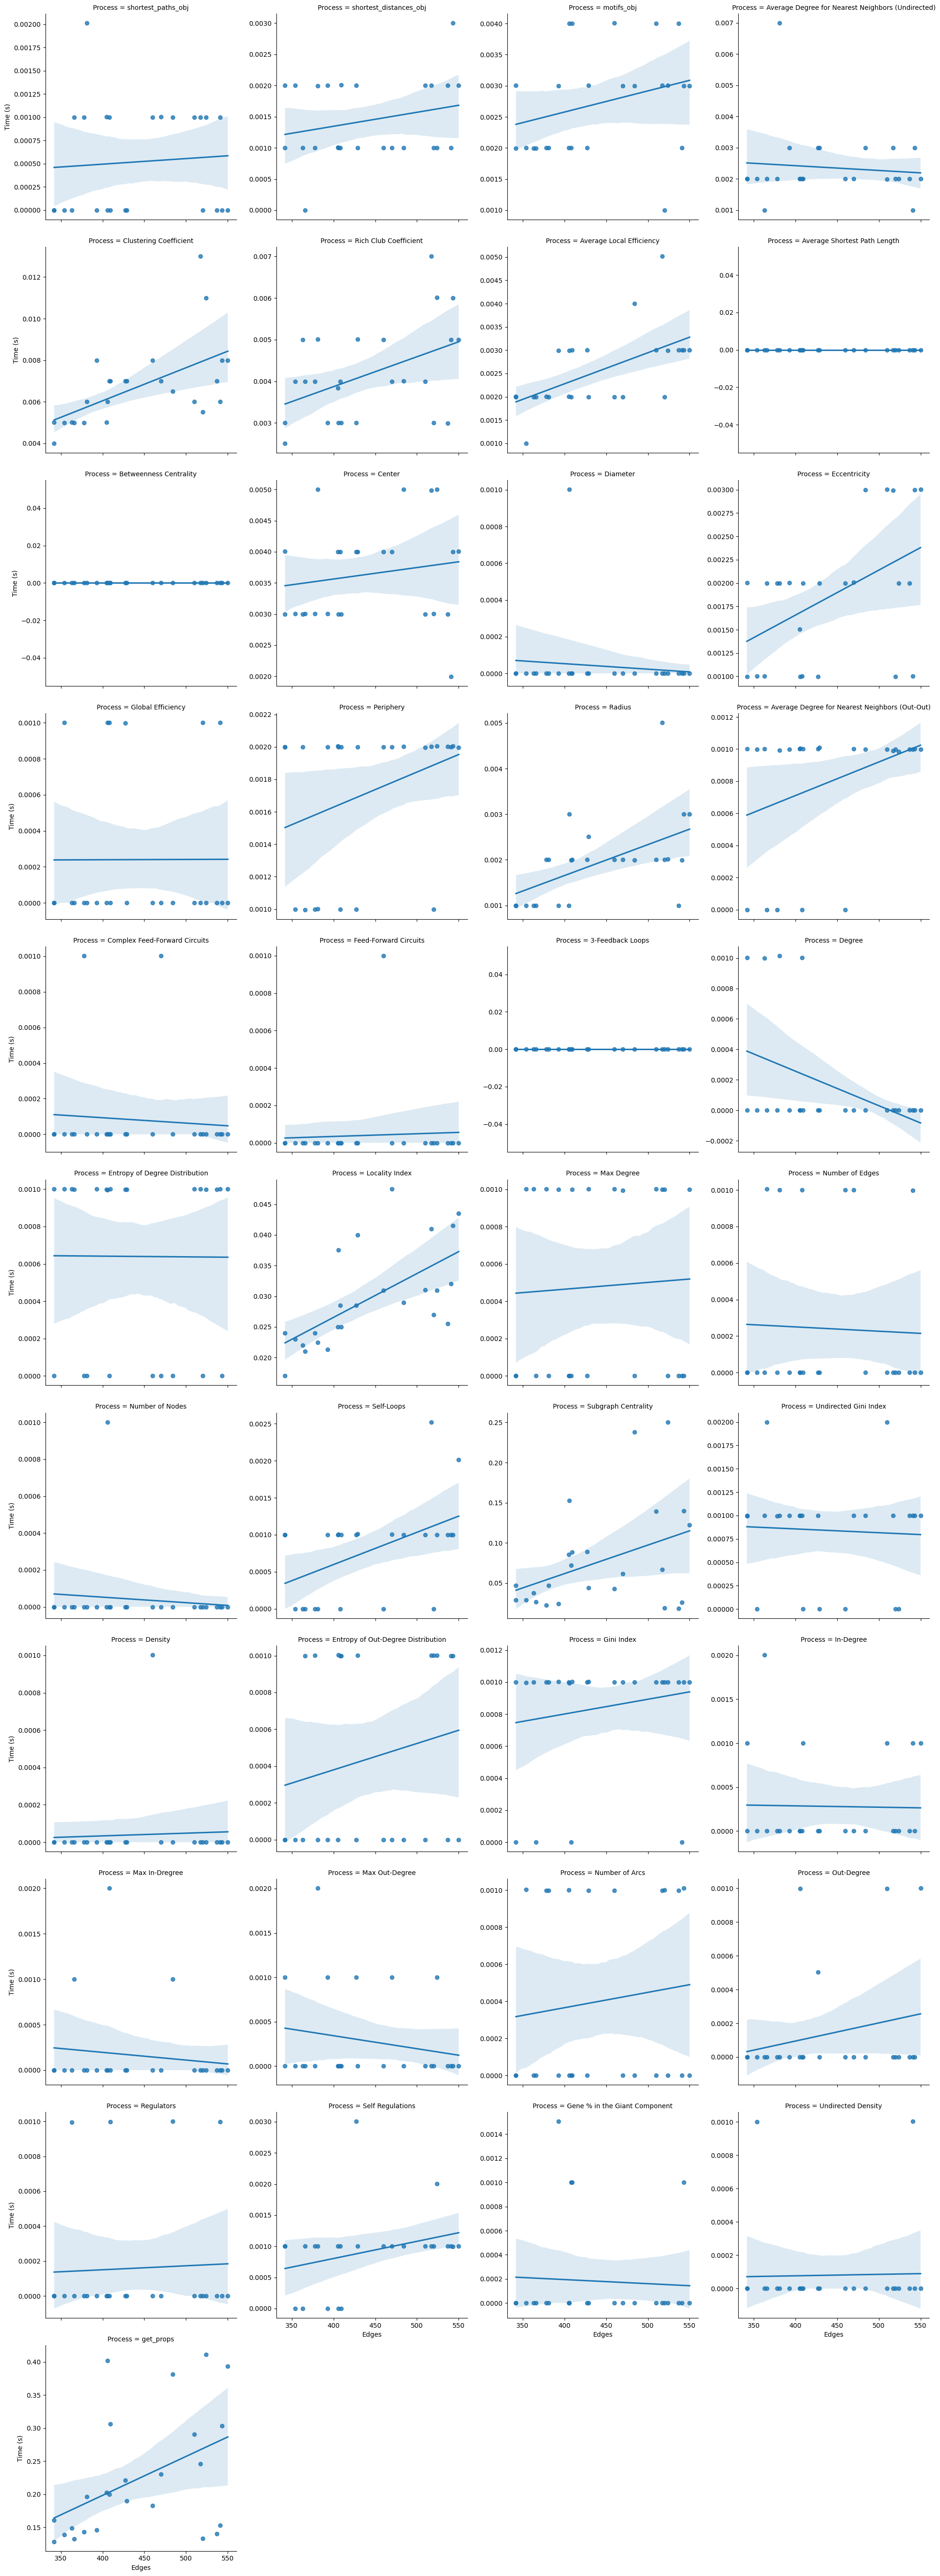

In [7]:
sns.lmplot(x='Edges', y='Time (s)', data=final_df, col='Process', height= 5, aspect= 1, sharey=False, col_wrap=4)

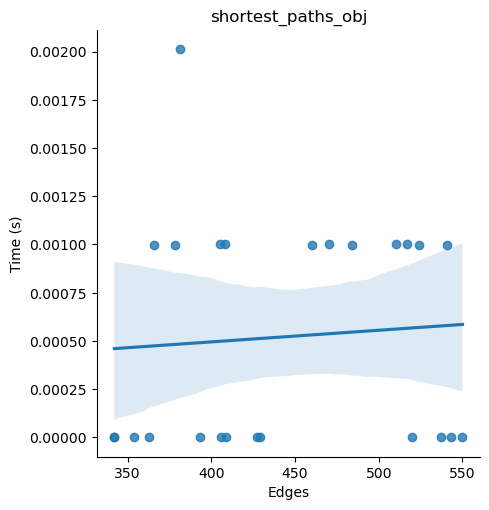

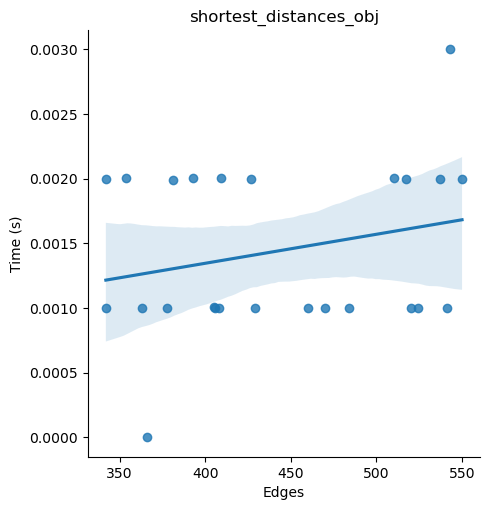

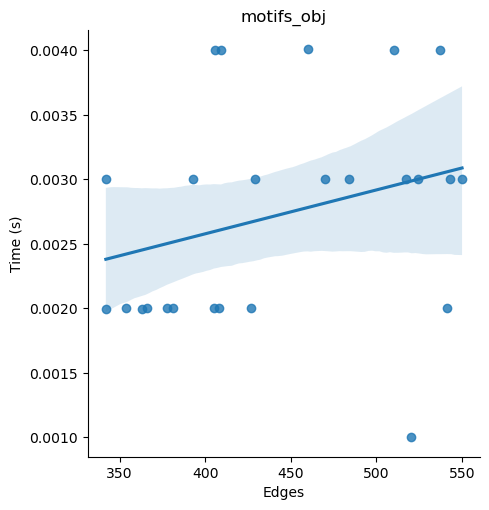

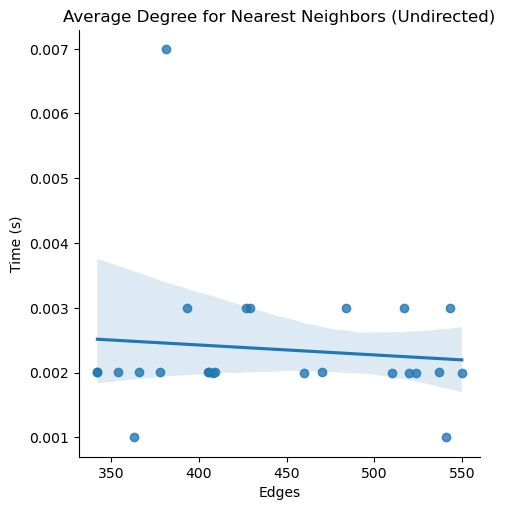

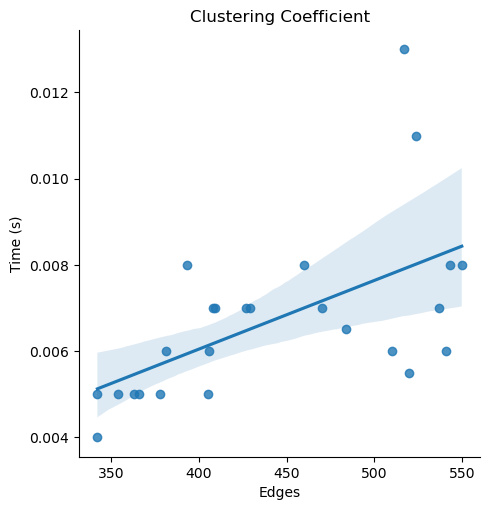

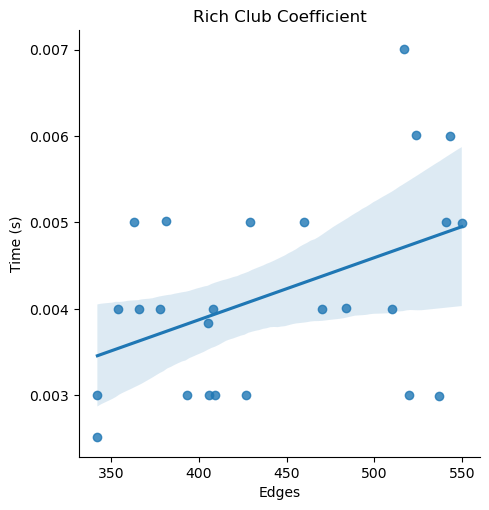

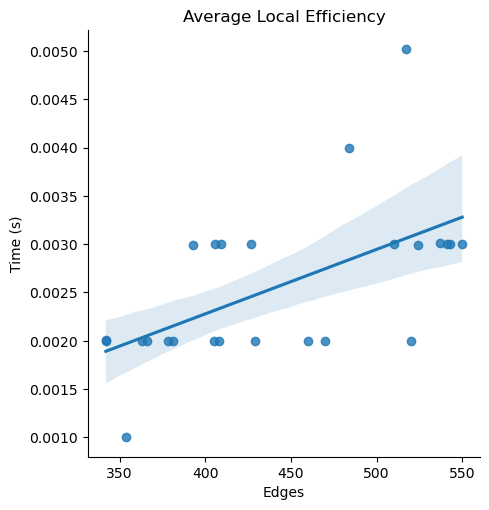

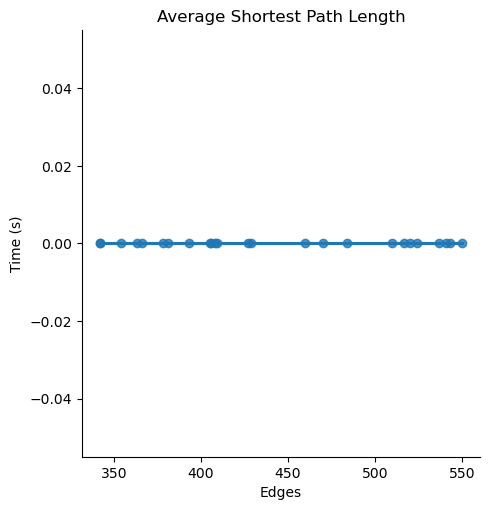

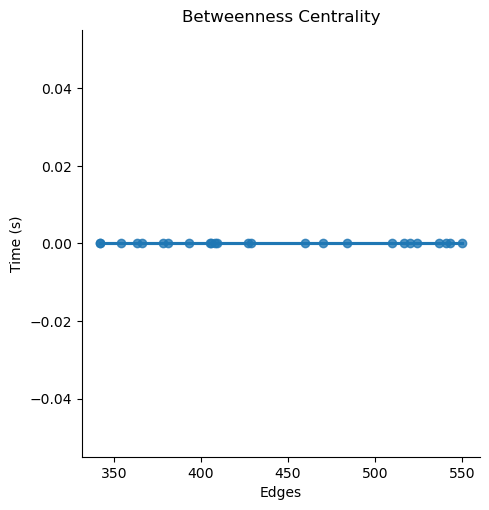

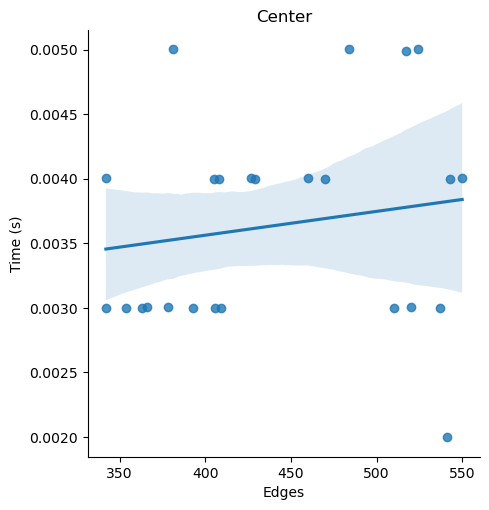

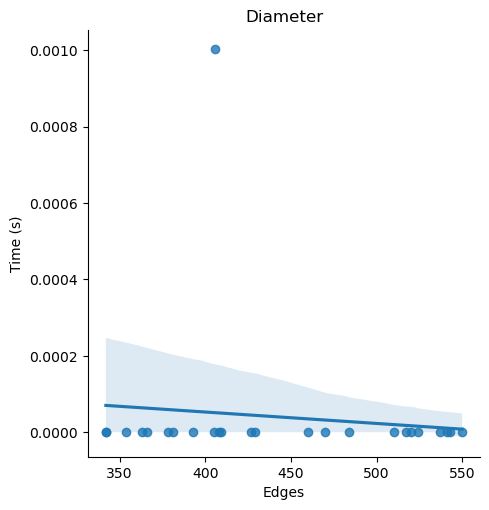

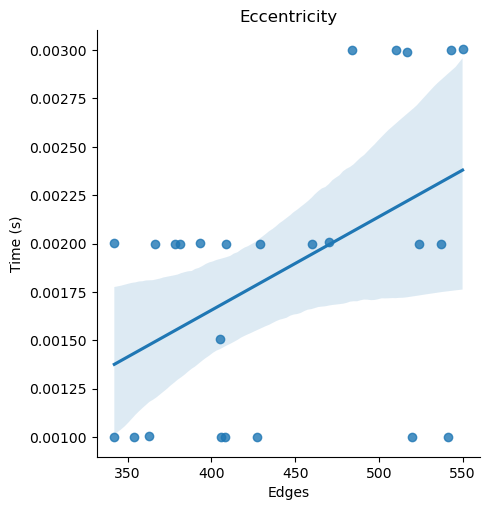

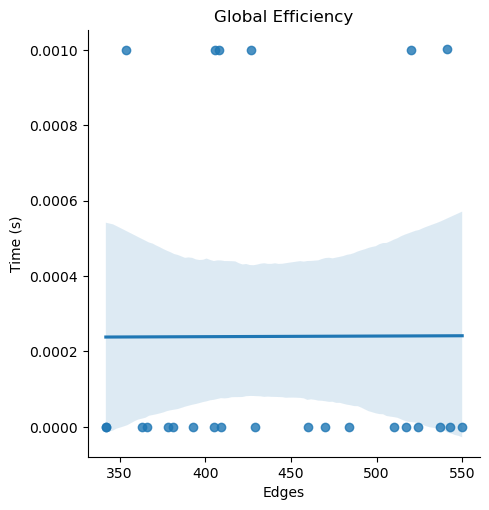

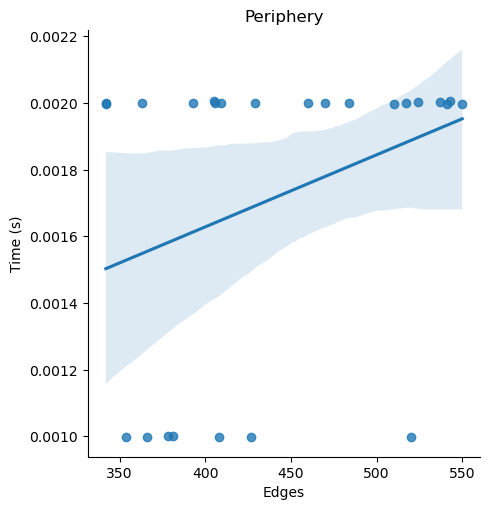

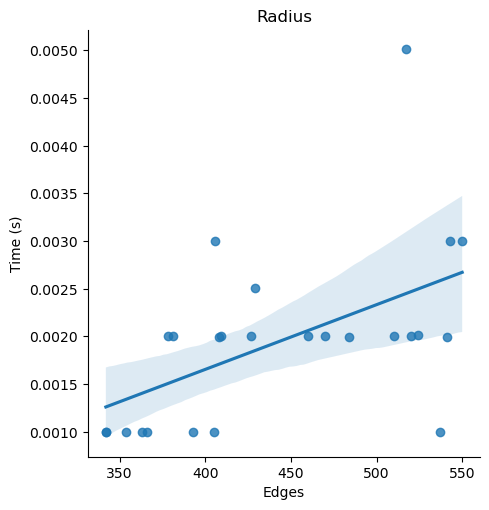

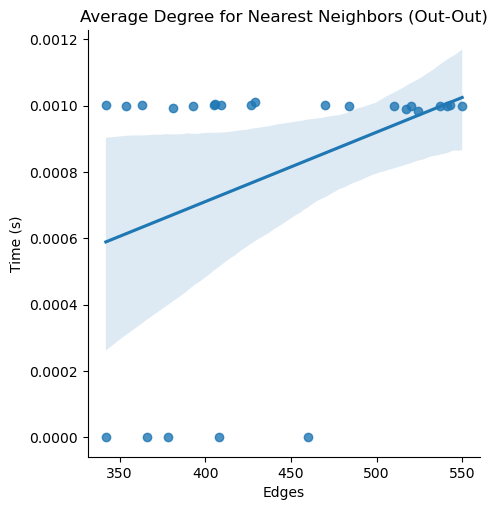

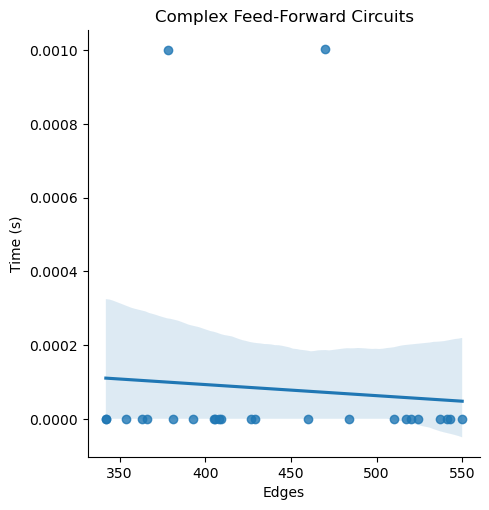

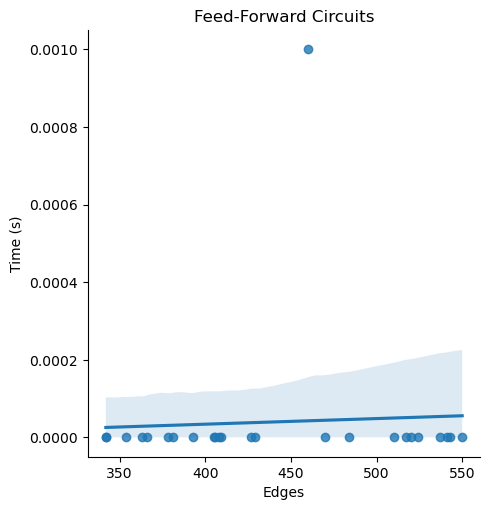

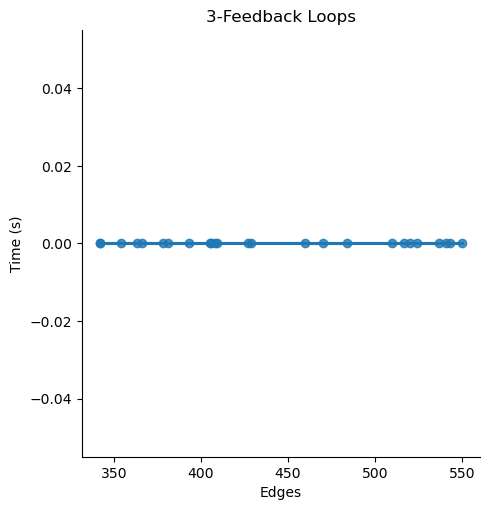

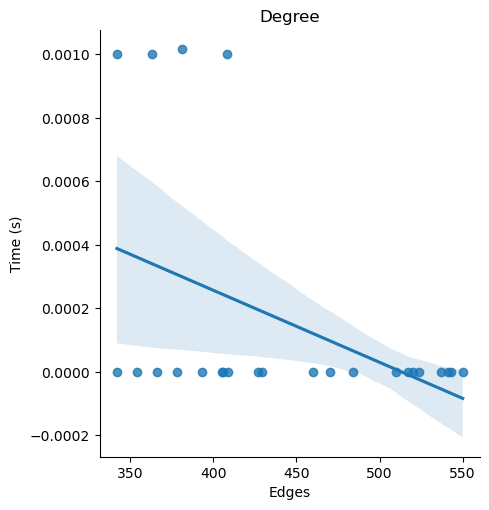

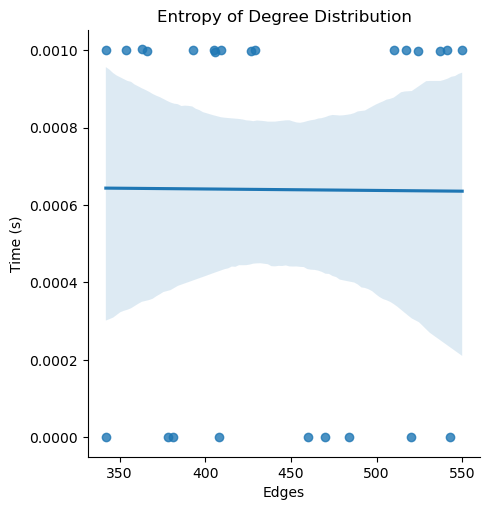

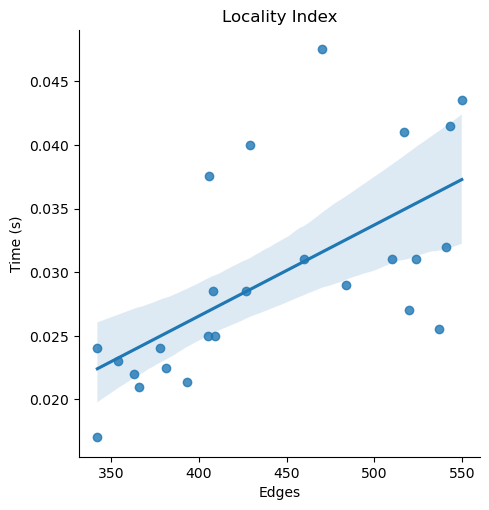

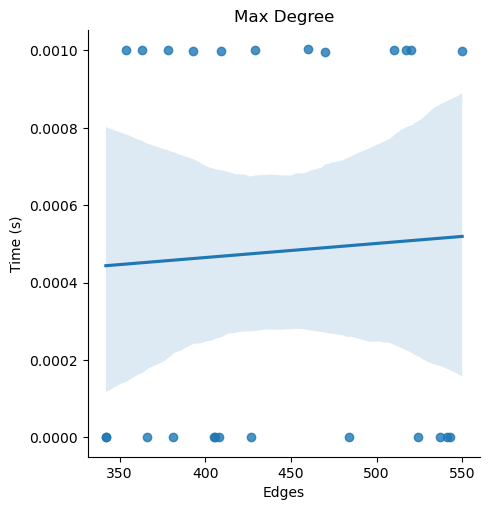

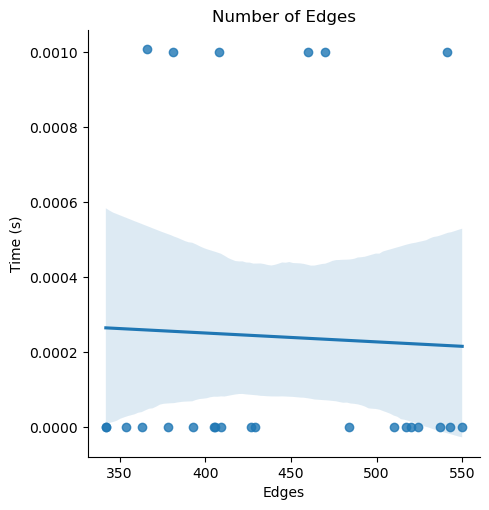

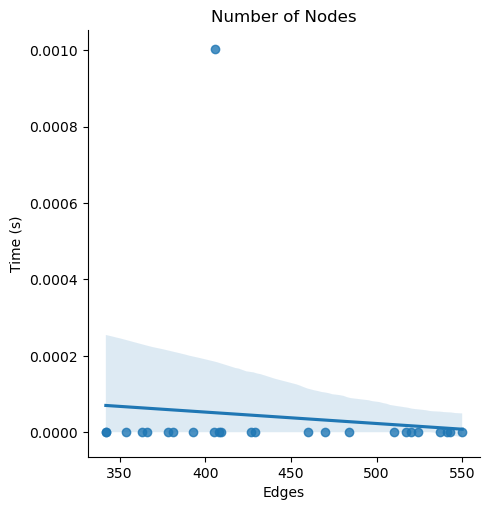

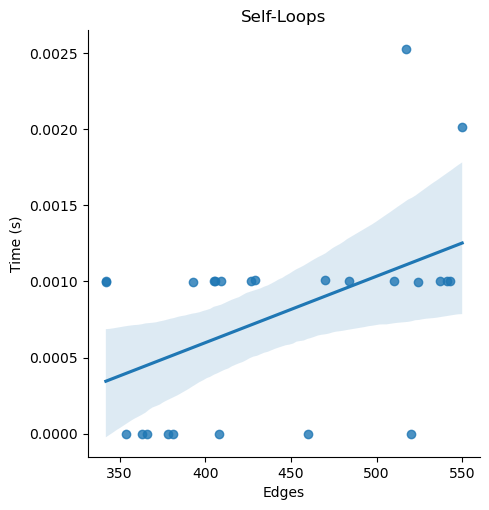

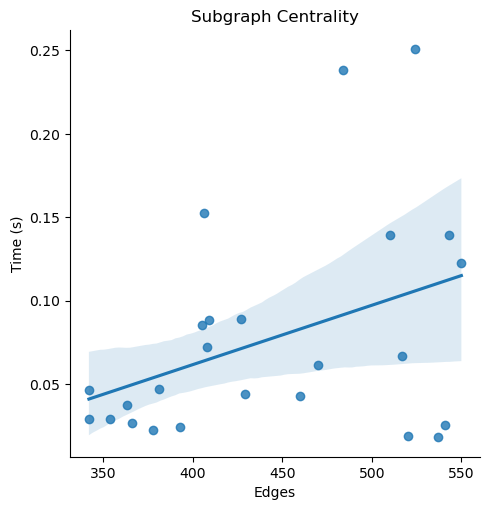

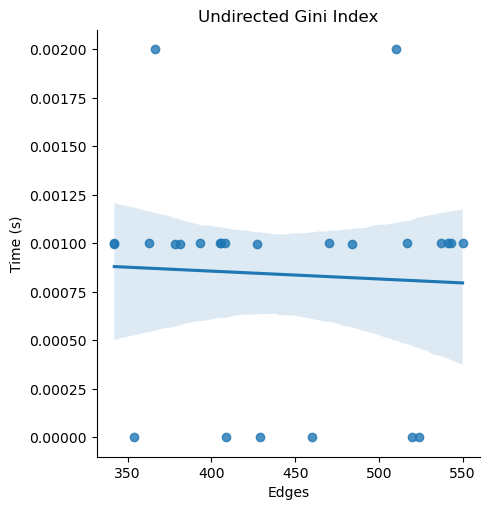

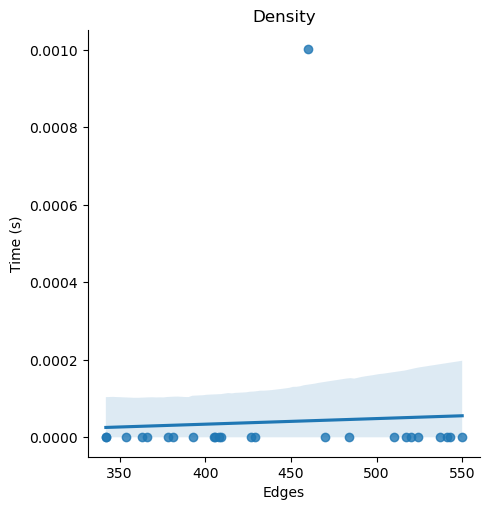

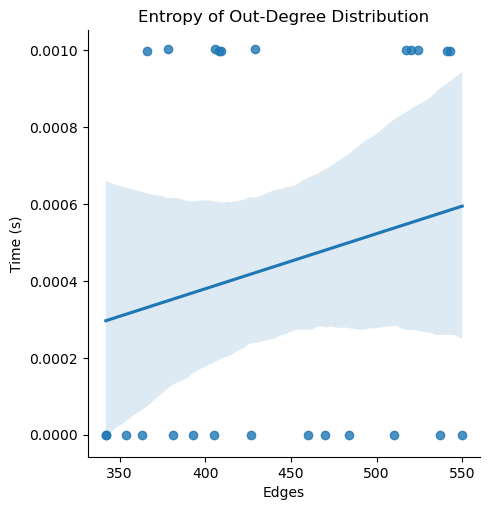

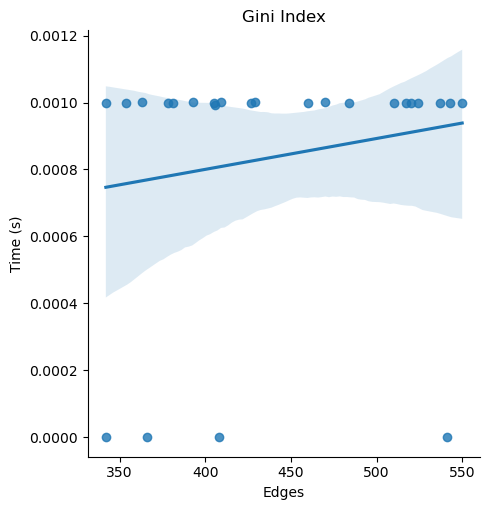

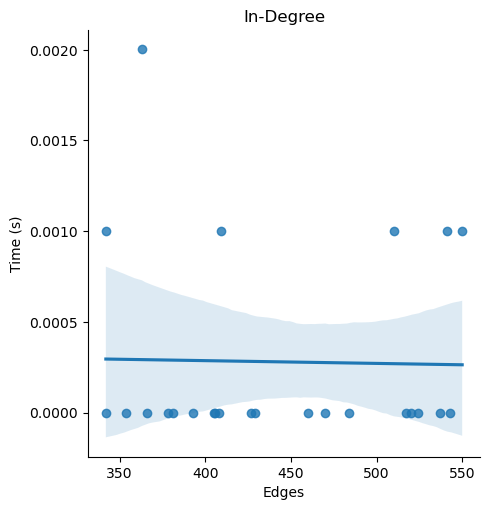

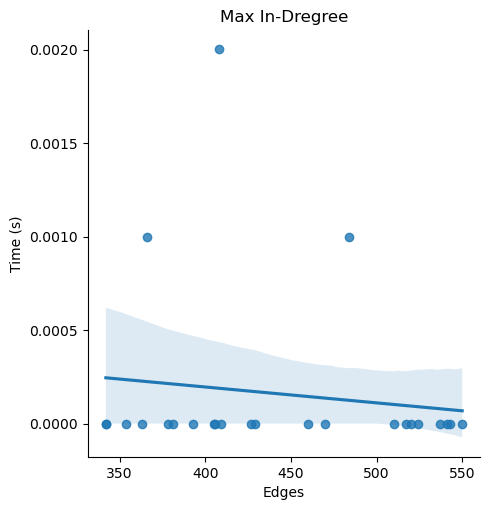

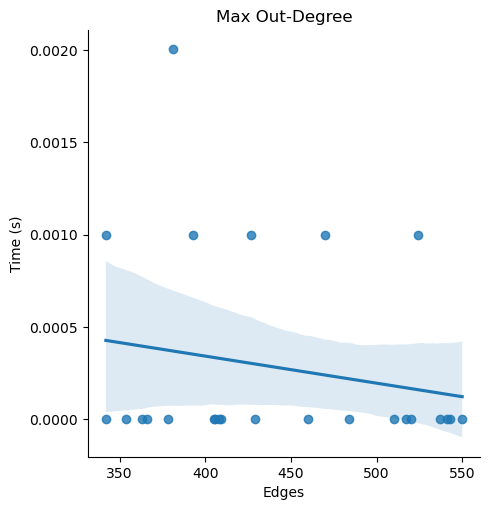

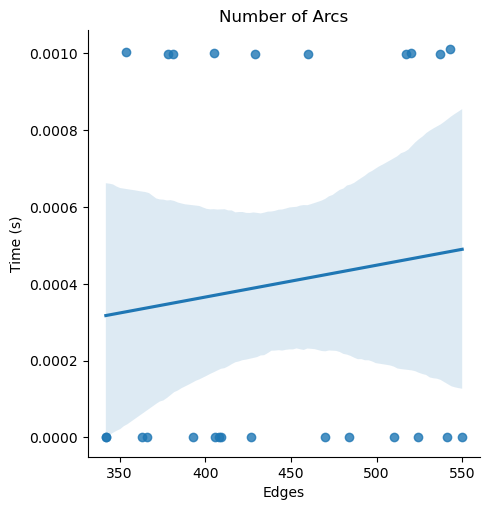

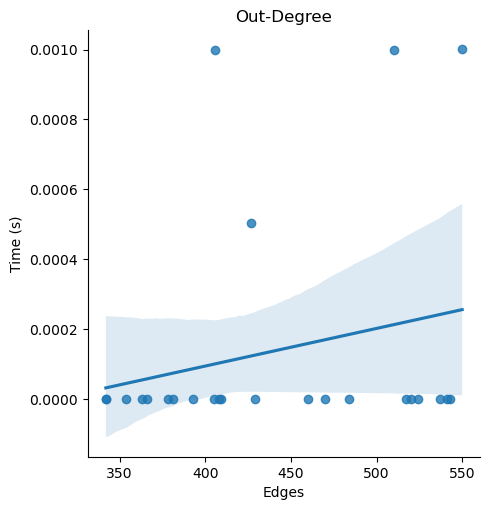

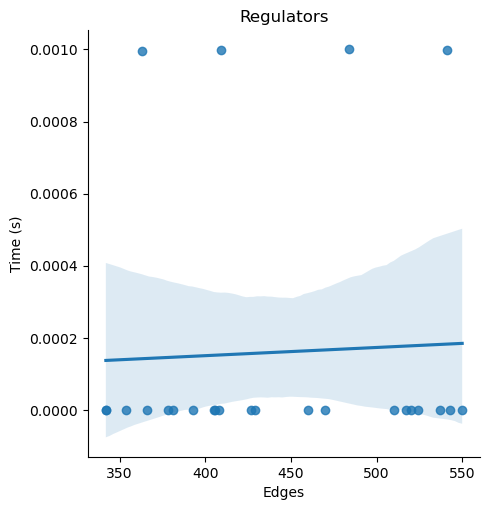

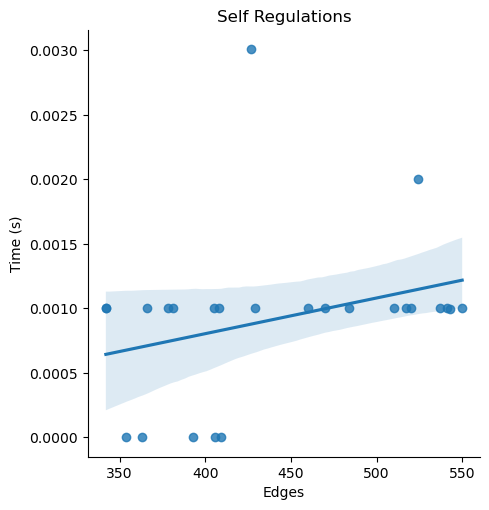

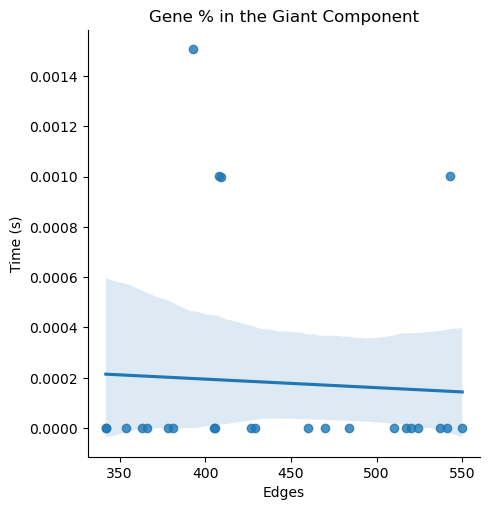

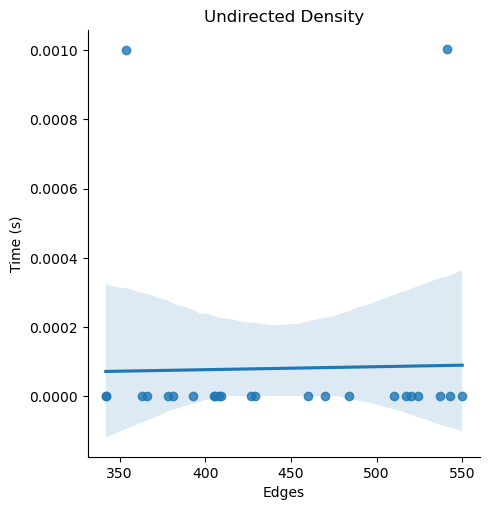

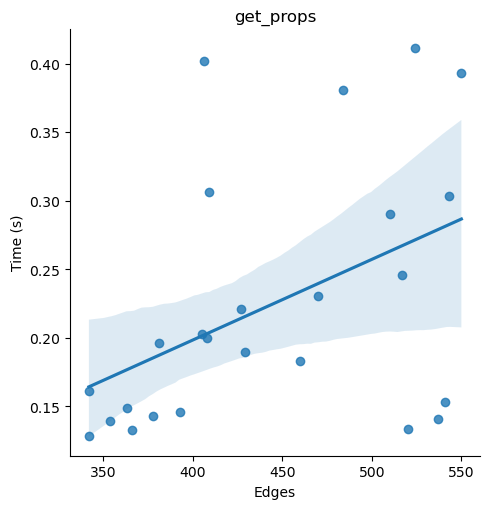

In [8]:
for prop, times in raw_times.items():
    if prop != 'edges' and prop != 'nodes':
        ax = sns.lmplot(
            data = raw_df,
            x = 'edges',
            y = prop, 
        )
        ax.set(
            xlabel='Edges',
            ylabel='Time (s)',
            title= prop
        )
        plt.show()